### RaschPy bivector MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the bivector parameterisation, each rater's severity is an additive combination of a per-item leniency effect and a per-threshold consistency effect, allowing rater behaviour to vary systematically across the latent continuum without the full item x threshold flexibility (and parameter cost) of the matrix model. It functions as rater-as-RSM, as opposed to the matrix formulation, which functions as rater-as-PCM.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Bivector(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:391: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_32781/3556847367.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Bivector(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_bivector_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_bivector_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     3.0     3.0     3.0     1.0     4.0     5.0     3.0   
        Person_2     0.0     0.0     2.0     1.0     2.0     3.0     1.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     2.0     4.0      2.0      2.0      2.0  
        Person_2     0.0     2.0      1.0      0.0      0.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the bivector parameterisation (a per-item leniency effect plus a per-threshold consistency effect for each rater). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_bivector()

CPU times: user 12.5 ms, sys: 276 μs, total: 12.7 ms
Wall time: 12.6 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -0.936370
Item_2   -0.455428
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


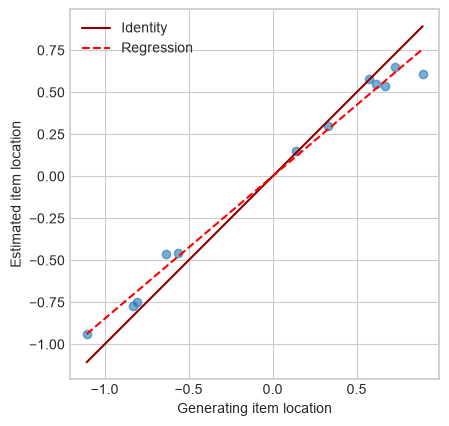

item location Pearson correlation:              0.994
item location SD ratio (estimated / generating): 0.853
item location regression coefficient:            0.848
item location RMSE:                              0.124


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_bivector_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_bivector(full=True)
mfrm.item_stats_bivector.to_csv('mfrm_bivector_item_stats.csv')

CPU times: user 25.7 s, sys: 113 ms, total: 25.8 s
Wall time: 25.7 s


Check the item statistics table

In [14]:
mfrm.item_stats_bivector

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,-0.936,0.044,-1.021,-0.854,1600,0.692,0.910,-2.611,0.916,-2.427,0.691,0.655
Item_2,-0.455,0.033,-0.523,-0.395,1600,0.603,0.916,-2.424,0.969,-0.881,0.694,0.670
Item_3,-0.748,0.040,-0.827,-0.679,1600,0.647,0.934,-1.883,0.961,-1.094,0.706,0.678
Item_4,0.577,0.038,0.509,0.656,1600,0.411,0.916,-2.423,0.921,-2.288,0.743,0.714
Item_5,-0.775,0.035,-0.842,-0.705,1600,0.654,0.860,-4.158,0.879,-3.567,0.704,0.681
Item_6,0.151,0.031,0.086,0.211,1600,0.482,0.904,-2.795,0.878,-3.577,0.743,0.708
Item_7,0.550,0.040,0.474,0.633,1600,0.401,0.879,-3.565,0.916,-2.431,0.759,0.729
Item_8,0.301,0.036,0.232,0.370,1600,0.458,0.922,-2.243,0.947,-1.527,0.750,0.732
Item_9,-0.465,0.036,-0.539,-0.404,1600,0.618,0.954,-1.318,0.980,-0.570,0.701,0.708
Item_10,0.611,0.038,0.530,0.685,1600,0.364,0.988,-0.316,0.981,-0.515,0.727,0.718


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_bivector(full=True)
mfrm.threshold_stats_bivector.to_csv('mfrm_bivector_threshold_stats.csv')

CPU times: user 84.8 ms, sys: 1.67 ms, total: 86.4 ms
Wall time: 86.3 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_bivector

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-0.952,0.041,-1.030,-0.867,1.014,1.296,1.019,1.190,0.952,0.375,0.356
Threshold 2,-0.897,0.038,-0.970,-0.825,0.981,-1.872,0.970,-2.215,1.079,0.394,0.341
Threshold 3,-0.723,0.031,-0.778,-0.661,0.977,-2.350,0.976,-1.635,1.059,0.472,0.421
Threshold 4,0.934,0.028,0.874,0.987,0.948,-5.750,0.934,-5.135,1.152,0.604,0.509
Threshold 5,1.638,0.046,1.539,1.716,0.971,-2.524,0.982,-1.046,1.076,0.625,0.587


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

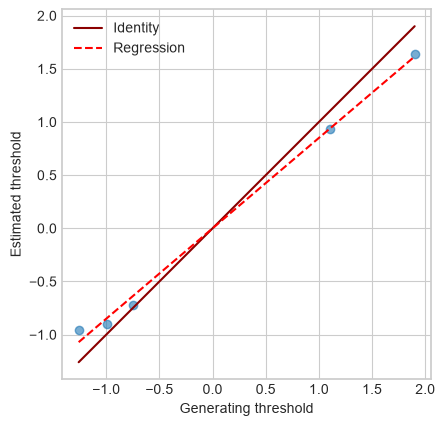

threshold Pearson correlation:              0.998
threshold SD ratio (estimated / generating): 0.852
threshold regression coefficient:            0.85
threshold RMSE:                              0.202


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_bivector_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file. `rater_stats_df_bivector` reports per-item marginal severities, then per-threshold marginal severities, plus overall fit statistics for each rater.

In [18]:
%%time
mfrm.rater_stats_df_bivector()
mfrm.rater_stats_bivector.to_csv('mfrm_bivector_rater_stats.csv')

CPU times: user 43.1 ms, sys: 912 μs, total: 44 ms
Wall time: 43.9 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_bivector

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    0.439  0.103    0.453  0.112    0.838  0.115   -0.140  0.113   
Rater_2    0.529  0.109    0.987  0.127    0.347  0.100   -0.037  0.110   
Rater_3    0.626  0.126    0.137  0.103   -0.368  0.110   -0.079  0.106   
Rater_4   -0.527  0.128   -1.006  0.123   -0.057  0.109   -0.415  0.109   
Rater_5   -0.694  0.121   -0.807  0.122   -0.605  0.121   -0.758  0.124   
Rater_6    0.018  0.104   -0.026  0.102   -0.421  0.110    0.422  0.119   
Rater_7   -0.719  0.123    0.390  0.102    0.269  0.108    1.012  0.144   
Rater_8    0.327  0.106   -0.127  0.102   -0.002  0.101   -0.004  0.101   

          Item_5         ... Threshold 2 Threshold 3        Threshold 4  \
        Estimate     SE  ...          SE    Estimate     SE    Estimate   
Rater_1    0.855  0.125  ...       0.079       0.238  0.073       0.233   
Rater_2    0.303  0.104  ...       0.086       0.261  0.063       0.007   
Rater_3   -0.397  0.111  ...       0.089      -0.194  0.069       0.294   
Rater_4    0.106  0.110  ...       0.104      -0.285  0.075       0.030   
Rater_5   -0.072  0.102  ...       0.101       0.440  0.070      -0.591   
Rater_6   -0.020  0.103  ...       0.088      -0.128  0.068      -0.117   
Rater_7   -0.079  0.094  ...       0.090      -0.223  0.071       0.176   
Rater_8   -0.695  0.116  ...       0.086      -0.109  0.063      -0.033   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.072      -0.138  0.080             2400.0    0.961     0.964  
Rater_2  0.066       0.313  0.087             2400.0    0.900     0.884  
Rater_3  0.067      -0.231  0.077             2400.0    0.911     0.923  
Rater_4  0.067      -0.245  0.068             2400.0    0.930     0.975  
Rater_5  0.068       0.344  0.071             2400.0    0.873     0.904  
Rater_6  0.070       0.096  0.082             2400.0    0.866     0.886  
Rater_7  0.069      -0.309  0.083             2400.0    0.962     0.993  
Rater_8  0.069       0.170  0.081             2400.0    0.900     0.936  

[8 rows x 37 columns]

The bivector model has two separate rater-effect components — a per-item leniency effect and a per-threshold consistency effect — so there are two recovery checks, against `mfrm.generating.item_effects` and `mfrm.generating.threshold_effects` respectively:

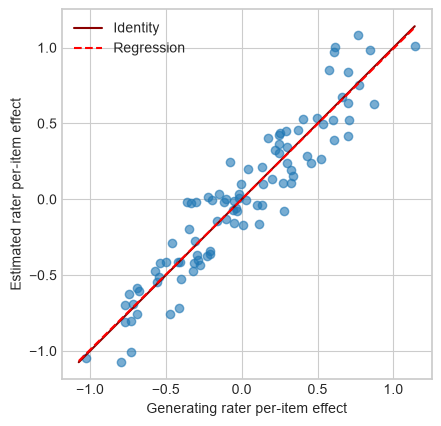

rater per-item effect Pearson correlation:              0.94
rater per-item effect SD ratio (estimated / generating): 1.056
rater per-item effect regression coefficient:            0.993
rater per-item effect RMSE:                              0.169


In [20]:
orig_item_effects = mfrm.generating.item_effects.stack()
est_item_effects = mfrm.raters_bivector_items.stack()
recovery_plot(orig_item_effects, est_item_effects, 'rater per-item effect', 'my_mfrm_bivector_rater_item_recovery.png')

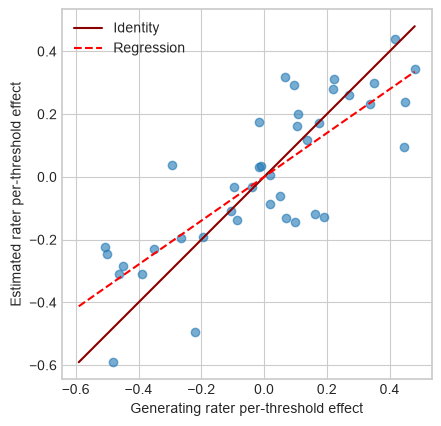

rater per-threshold effect Pearson correlation:              0.805
rater per-threshold effect SD ratio (estimated / generating): 0.867
rater per-threshold effect regression coefficient:            0.698
rater per-threshold effect RMSE:                              0.165


In [21]:
orig_threshold_effects = mfrm.generating.threshold_effects.stack()
est_threshold_effects = mfrm.raters_bivector_thresholds.stack()
recovery_plot(orig_threshold_effects, est_threshold_effects, 'rater per-threshold effect', 'my_mfrm_bivector_rater_threshold_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [22]:
%%time
mfrm.person_stats_df_bivector(full=True)
mfrm.person_stats_bivector.to_csv('mfrm_bivector_person_stats.csv')

CPU times: user 13.4 ms, sys: 770 μs, total: 14.1 ms
Wall time: 14 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [23]:
mfrm.person_stats_bivector.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,0.371,0.102,0.107,291,480,0.606,1.103,1.127,0.736,0.898
Person_2,-1.180,0.102,0.104,129,480,0.269,1.043,1.001,0.348,0.062
Person_3,0.989,0.113,0.103,345,480,0.719,0.834,0.887,-1.106,-0.743
Person_4,1.242,0.118,0.117,364,480,0.758,0.972,0.962,-0.130,-0.205
Person_5,-2.430,0.151,0.161,39,480,0.081,1.133,0.848,0.669,-0.439
Person_6,-1.542,0.109,0.108,96,480,0.200,0.978,1.062,-0.095,0.375
Person_7,0.238,0.100,0.088,278,480,0.579,0.765,0.780,-1.760,-1.630
Person_8,-0.315,0.096,0.090,220,480,0.458,0.874,0.912,-0.935,-0.602
Person_9,0.032,0.098,0.089,257,480,0.535,0.820,0.814,-1.344,-1.361
Person_10,-0.999,0.099,0.091,147,480,0.306,0.840,0.806,-1.179,-1.274


And the same recovery check for person locations, against `mfrm.generating.persons`:

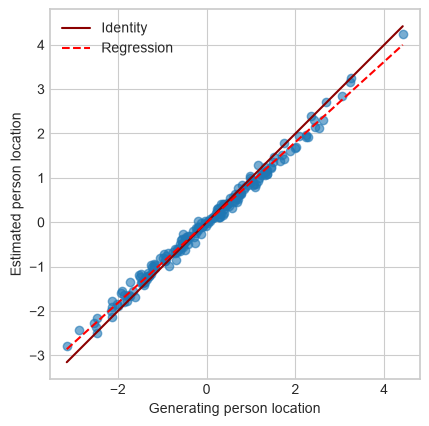

person location Pearson correlation:              0.996
person location SD ratio (estimated / generating): 0.91
person location regression coefficient:            0.906
person location RMSE:                              0.165


In [24]:
recovery_plot(mfrm.generating.persons, mfrm.persons_bivector, 'person location', 'my_mfrm_bivector_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [25]:
%%time
mfrm.test_stats_df_bivector()
mfrm.test_stats_bivector.to_csv('mfrm_bivector_test_stats.csv')

CPU times: user 2.48 ms, sys: 264 μs, total: 2.74 ms
Wall time: 2.78 ms


Check the test statistics table

In [26]:
mfrm.test_stats_bivector

,Items,Persons
Mean,-0.000,-0.004
SD,0.625,1.203
Separation ratio,16.913,11.022
Strata,22.884,15.029
Reliability,0.997,0.992


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [27]:
%%time
mfrm.item_res_corr_analysis_bivector()
mfrm.item_residual_correlations_bivector.to_csv('mfrm_bivector_item_residual_correlations.csv')
mfrm.item_loadings_bivector.to_csv('mfrm_bivector_item_loadings.csv')

CPU times: user 5.49 ms, sys: 1.53 ms, total: 7.02 ms
Wall time: 8.22 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [28]:
round(mfrm.item_residual_correlations_bivector, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.025,0.022,-0.017,-0.007,-0.010,-0.025,-0.019,0.017,-0.041,-0.005,-0.019
Item_2,-0.025,1.000,0.016,-0.006,0.002,-0.027,0.018,-0.030,0.022,-0.014,-0.018,-0.019
Item_3,0.022,0.016,1.000,-0.058,-0.007,0.035,-0.044,-0.060,-0.008,-0.042,0.018,0.017
Item_4,-0.017,-0.006,-0.058,1.000,-0.008,-0.050,0.020,-0.000,-0.004,0.013,-0.002,-0.006
Item_5,-0.007,0.002,-0.007,-0.008,1.000,-0.018,0.009,0.005,0.000,0.015,-0.023,0.011
Item_6,-0.010,-0.027,0.035,-0.050,-0.018,1.000,-0.049,0.001,-0.000,0.007,-0.008,0.003
Item_7,-0.025,0.018,-0.044,0.020,0.009,-0.049,1.000,-0.014,0.027,0.027,-0.017,0.028
Item_8,-0.019,-0.030,-0.060,-0.000,0.005,0.001,-0.014,1.000,-0.008,-0.031,-0.006,-0.046
Item_9,0.017,0.022,-0.008,-0.004,0.000,-0.000,0.027,-0.008,1.000,-0.026,-0.005,0.056
Item_10,-0.041,-0.014,-0.042,0.013,0.015,0.007,0.027,-0.031,-0.026,1.000,0.009,-0.026


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [29]:
round(mfrm.item_loadings_bivector['PC 1'], 3)

Item_1     0.092
Item_2    -0.013
Item_3     0.194
Item_4    -0.146
Item_5    -0.040
Item_6     0.128
Item_7    -0.138
Item_8    -0.062
Item_9     0.011
Item_10   -0.100
Item_11    0.037
Item_12    0.035
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [30]:
%%time
mfrm.rater_res_corr_analysis_bivector()
mfrm.rater_residual_correlations_bivector.to_csv('mfrm_bivector_rater_residual_correlations.csv')
mfrm.rater_loadings_bivector.to_csv('mfrm_bivector_rater_loadings.csv')

CPU times: user 9.97 ms, sys: 539 μs, total: 10.5 ms
Wall time: 10.5 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [31]:
round(mfrm.rater_residual_correlations_bivector, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.009,-0.002,0.006,0.006,-0.000,0.012,-0.008
Rater_2,0.009,1.000,0.005,-0.038,0.010,-0.027,0.014,-0.003
Rater_3,-0.002,0.005,1.000,-0.047,-0.020,-0.006,-0.010,-0.040
Rater_4,0.006,-0.038,-0.047,1.000,-0.018,-0.031,-0.016,-0.023
Rater_5,0.006,0.010,-0.020,-0.018,1.000,-0.009,-0.013,-0.012
Rater_6,-0.000,-0.027,-0.006,-0.031,-0.009,1.000,-0.009,-0.020
Rater_7,0.012,0.014,-0.010,-0.016,-0.013,-0.009,1.000,-0.013
Rater_8,-0.008,-0.003,-0.040,-0.023,-0.012,-0.020,-0.013,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [32]:
mfrm.rater_loadings_bivector['PC 1']

Rater_1    0.015533
Rater_2   -0.170654
Rater_3   -0.207674
Rater_4    0.265104
Rater_5   -0.001866
Rater_6   -0.055181
Rater_7   -0.013545
Rater_8    0.137582
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

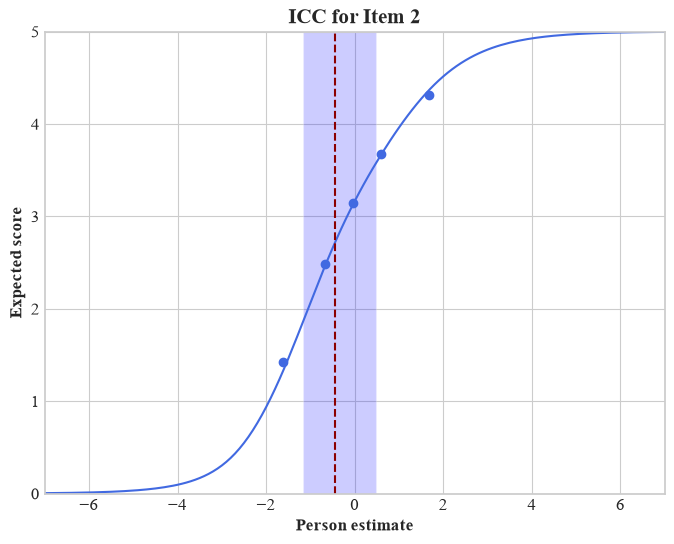

In [33]:
mfrm.icc_bivector('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_bivector_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

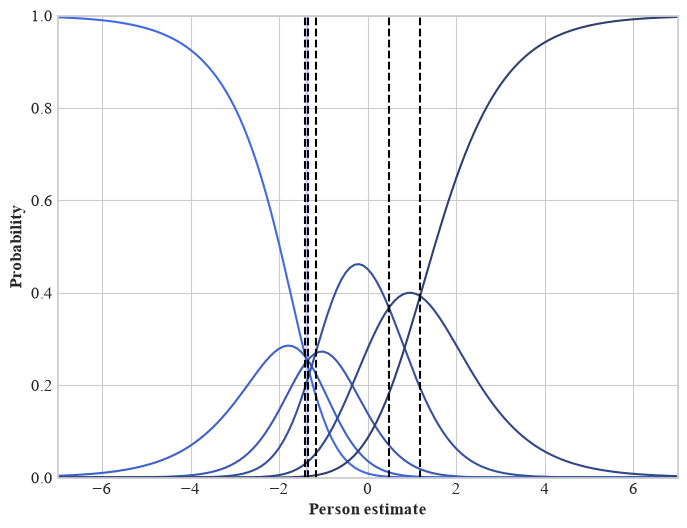

In [34]:
mfrm.crcs_bivector('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bivector_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

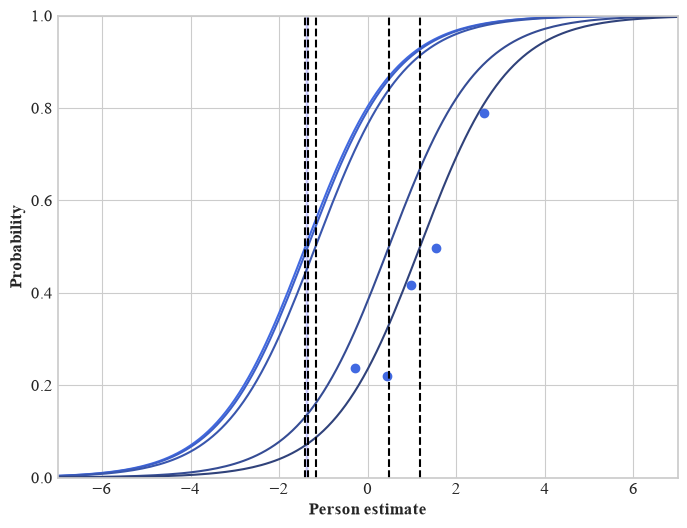

In [35]:
mfrm.threshold_ccs_bivector('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bivector_threshold_ccs')

Produce an item information function curve for Item 2

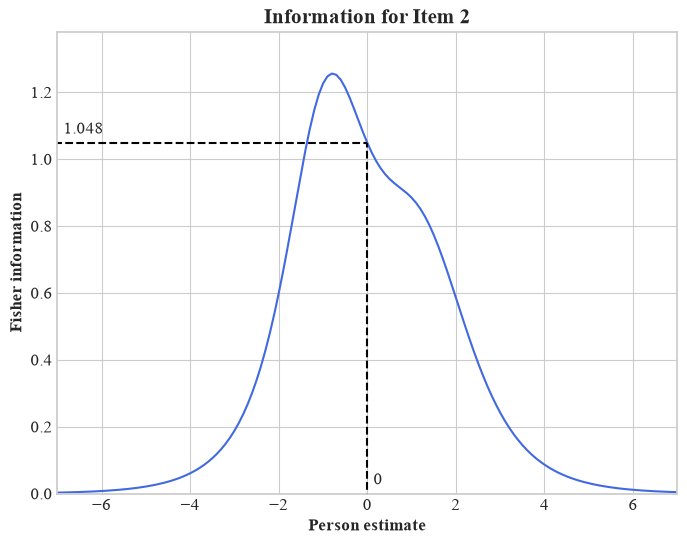

In [36]:
mfrm.iic_bivector('Item_2', point_info_lines=[0], point_info_labels=True, title='Information for Item 2',
                  xmin=-7, xmax=7, filename='my_mfrm_bivector_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

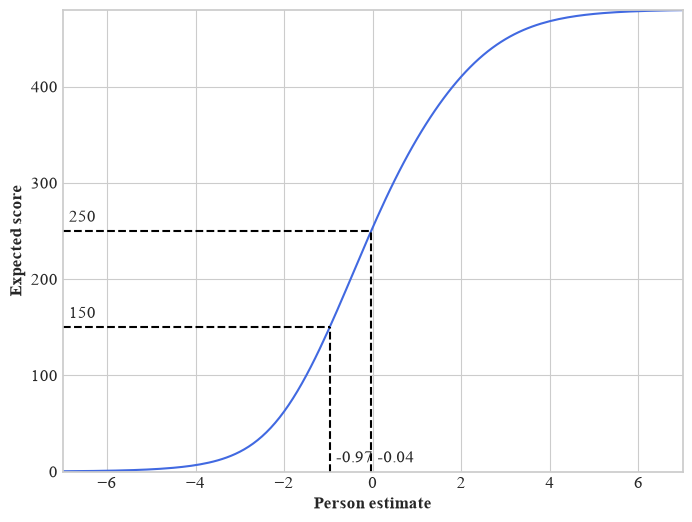

In [37]:
mfrm.tcc_bivector(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bivector_tcc')

Produce a test information curve

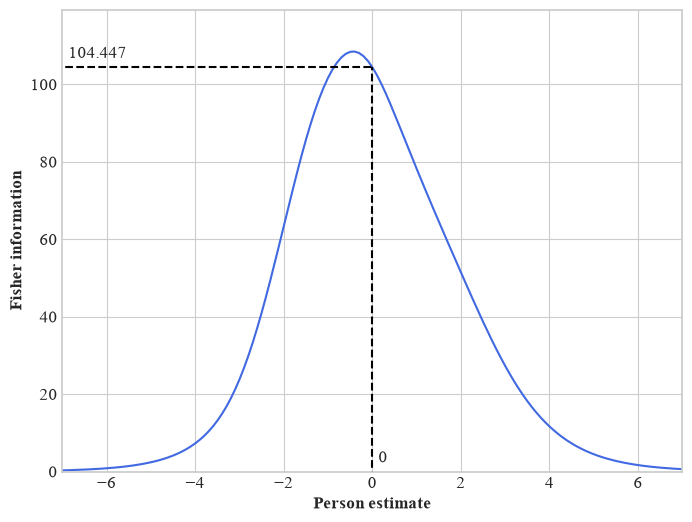

In [38]:
mfrm.test_info_bivector(point_info_lines=[0], point_info_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bivector_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

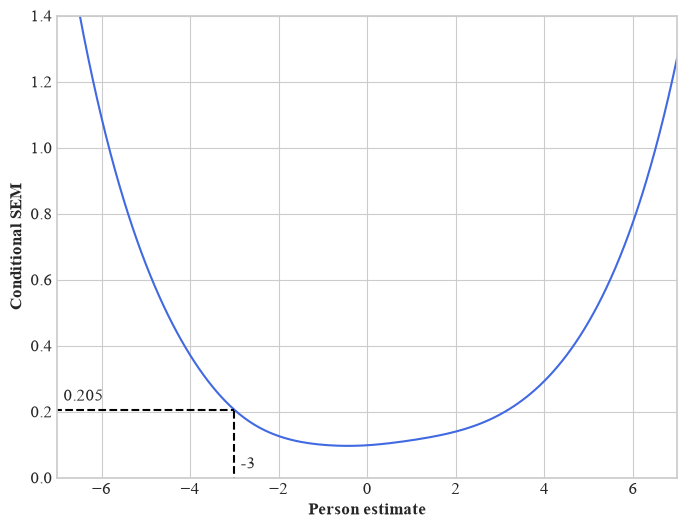

In [39]:
mfrm.test_csem_bivector(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_bivector_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

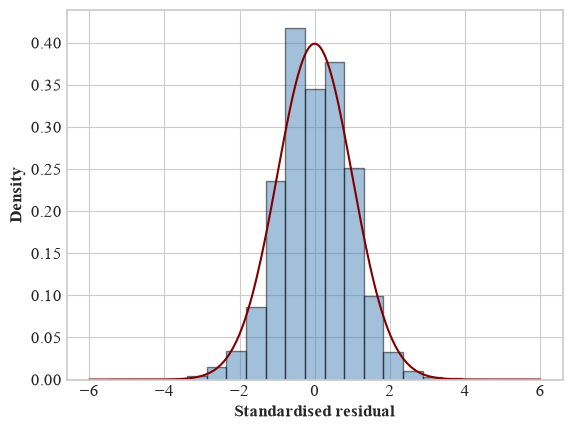

In [40]:
mfrm.std_residuals_plot_bivector(bin_width=0.6, normal=True, filename='my_mfrm_bivector_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [41]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_bivector_anchor(anchors)

CPU times: user 8.21 ms, sys: 324 μs, total: 8.53 ms
Wall time: 8.46 ms


Check the anchored item locations against the unanchored ones.

In [42]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_bivector})
round(item_check, 3)

,Unanchored,Anchored
Item_1,-0.936,-0.687
Item_2,-0.455,-0.330
Item_3,-0.748,-0.576
Item_4,0.577,0.392
Item_5,-0.775,-0.575
Item_6,0.151,-0.122
Item_7,0.550,0.412
Item_8,0.301,0.495
Item_9,-0.465,-0.471
Item_10,0.611,0.222


Check the anchored thresholds against the unanchored thresholds

In [43]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                                'Anchored': mfrm.anchor_thresholds_bivector})
round(threshold_check, 3)

,Unanchored,Anchored
1,-0.952,-1.068
2,-0.897,-0.851
3,-0.723,-0.718
4,0.934,1.076
5,1.638,1.562


Check the anchored per-item rater effects against the unanchored ones - two dataframes

In [44]:
round(mfrm.raters_bivector_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.439,0.453,0.838,-0.140,0.855,-0.586,0.405,0.202,-0.193,-0.413,0.034,1.084
Rater_2,0.529,0.987,0.347,-0.037,0.303,-0.804,-0.548,0.459,0.755,-0.422,0.098,0.103
Rater_3,0.626,0.137,-0.368,-0.079,-0.397,0.536,0.417,-0.341,-0.156,-0.274,0.238,0.154
Rater_4,-0.527,-1.006,-0.057,-0.415,0.106,-0.171,-0.755,0.525,-0.362,-0.377,-0.291,-1.074
Rater_5,-0.694,-0.807,-0.605,-0.758,-0.072,0.499,-0.014,-0.416,0.194,0.521,0.674,-1.045
Rater_6,0.018,-0.026,-0.421,0.422,-0.020,-0.472,0.249,-0.021,-0.019,1.003,-0.624,0.972
Rater_7,-0.719,0.390,0.269,1.012,-0.079,0.635,0.236,0.104,-0.432,-0.040,-0.163,0.283
Rater_8,0.327,-0.127,-0.002,-0.004,-0.695,0.362,0.010,-0.512,0.214,0.002,0.035,-0.476


In [45]:
round(mfrm.anchor_raters_bivector_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.172,0.311,0.648,0.028,0.638,-0.330,0.526,-0.009,-0.204,-0.042,0.014,1.017
Rater_2,0.262,0.845,0.157,0.131,0.086,-0.548,-0.428,0.248,0.744,-0.050,0.078,0.036
Rater_3,0.359,-0.006,-0.558,0.089,-0.614,0.793,0.537,-0.552,-0.167,0.097,0.218,0.087
Rater_4,-0.794,-1.149,-0.247,-0.247,-0.111,0.085,-0.635,0.314,-0.372,-0.005,-0.311,-1.141
Rater_5,-0.961,-0.950,-0.795,-0.590,-0.288,0.755,0.106,-0.627,0.183,0.892,0.654,-1.111
Rater_6,-0.249,-0.168,-0.611,0.590,-0.237,-0.215,0.369,-0.232,-0.030,1.375,-0.644,0.905
Rater_7,-0.986,0.247,0.079,1.180,-0.296,0.891,0.357,-0.107,-0.443,0.331,-0.183,0.217
Rater_8,0.060,-0.270,-0.192,0.163,-0.912,0.618,0.130,-0.724,0.203,0.373,0.016,-0.542


Check the anchored per-threshold rater effects against the unanchored ones - two dataframes

In [46]:
round(mfrm.raters_bivector_thresholds, 3)

,1,2,3,4,5
Rater_1,-0.142,-0.192,0.238,0.233,-0.138
Rater_2,-0.493,-0.088,0.261,0.007,0.313
Rater_3,-0.031,0.163,-0.194,0.294,-0.231
Rater_4,0.201,0.300,-0.285,0.030,-0.245
Rater_5,0.116,-0.310,0.440,-0.591,0.344
Rater_6,0.279,-0.130,-0.128,-0.117,0.096
Rater_7,0.037,0.318,-0.223,0.176,-0.309
Rater_8,0.034,-0.062,-0.109,-0.033,0.170


In [47]:
round(mfrm.anchor_raters_bivector_thresholds, 3)

,1,2,3,4,5
Rater_1,-0.026,-0.238,0.234,0.092,-0.062
Rater_2,-0.377,-0.134,0.256,-0.134,0.388
Rater_3,0.085,0.117,-0.199,0.153,-0.156
Rater_4,0.317,0.254,-0.290,-0.111,-0.170
Rater_5,0.233,-0.356,0.435,-0.732,0.420
Rater_6,0.395,-0.176,-0.133,-0.258,0.171
Rater_7,0.153,0.272,-0.228,0.035,-0.233
Rater_8,0.151,-0.108,-0.114,-0.174,0.246
